Smother Experiment: comparison of die-off of coastal birds in English Bay as a result of smothering from Bunker C whole oil to impacts from the PAH toxicity from the water soluble fraction of oil. Results are 3-day Atlantis output from 2019-2022 (spill years), and 2039-2042 (20 years after) for the EB-FlTs simulation.

In [1]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

In [2]:
English_Bay = [75]
hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
hex_colour = '#2F61A4'

In [3]:
line_styles = itertools.cycle(('-', '--', '-.', ':'))#,(5, (10, 3)),
#    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

In [4]:
# Read in salish sea atlantis output files.
control_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/')
#control_paths = sorted([p for p in control_root.glob('v6719_60d/outputSalishSea.nc')])
control_paths = sorted([p for p in control_root.glob('highres-control-3y-2*/outputSalishSea.nc')])
for path in control_paths:
    print(path.parent.stem)

highres-control-3y-2019-2022
highres-control-3y-2029-2032
highres-control-3y-2039-2042


In [5]:
control_datasets = [xr.open_dataset(cfile,decode_cf=True) for cfile in control_paths]

In [6]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/')

In [7]:
# start and end time of data display, after burn-in
start = 0
end = 365

In [8]:

scenario_paths = sorted([p for p in scenario_root.glob('6a_2019-07-16_2*/outputSalishSea.nc')])
scenario_names = []
for path in scenario_paths:
    print(path.parent.stem)
    nm = str(path.parent.stem).split(sep='_')
    scenario_loc = 'EB'
    scenario_names.append(scenario_loc+'-'+str(nm[1])+'-'+str(nm[2]))

6a_2019-07-16_2019-2022
6a_2019-07-16_2039-2042


In [9]:
print(scenario_names)

['EB-2019-07-16-2019-2022', 'EB-2019-07-16-2039-2042']


In [10]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

### Water column PAH

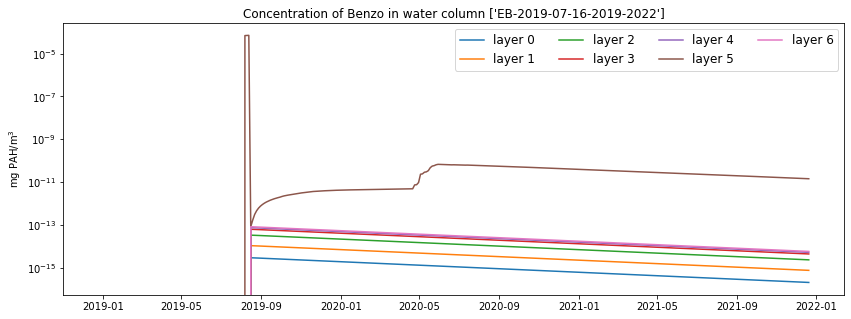

In [11]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[0:1],scenario_names[0:1]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[0:1]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

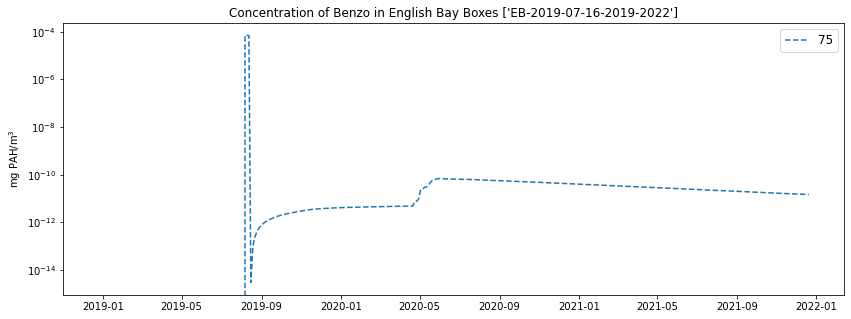

In [12]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[0:1],scenario_names[0:1]):
    contam_tbl = scenario.variables['Benzo'][start:end,English_Bay,:]
    contam_t = contam_tbl.sum(axis=2)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in English Bay Boxes '+str(scenario_names[0:1]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(English_Bay, fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

### Birds impacts

In [13]:
def plot_vert_biomass(bio_group, scenario_datasets, scenario_paths, control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1,1,1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        numCohorts = groups.cohorts[bio_group[species]]
        
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'EB-'+nm[2]  
            names.append(scenario_name)

            for cohort in range (1, numCohorts+1):

                new_species = bio_group[species] + str(cohort)
                    #this_linestyle=next(line_styles)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2))

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2))

                ax.plot(control.t, c_weightatage, linewidth = 2, color='black') #, label='control-'+scenario_name)
                ax.plot(scenario.t, o_weightatage, linewidth = 2, linestyle=':') #label=scenario_name, 
        ax.set_title(species)
        plt.ylabel('Biomass', fontsize=12)
        ax.set_ylim([y_min, y_max])
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels) #, fontsize=12
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1)) #, loc='lower right'

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `.Bbox`
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  contains: unknown
  figure: `.Figure`
  fontfamily or family: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'extra-expanded', 'ultra-expanded'}
  fontstyle or style: {'normal', 'italic', 'oblique'}
  fontvariant or variant: {'normal', 'small-caps'}
  font

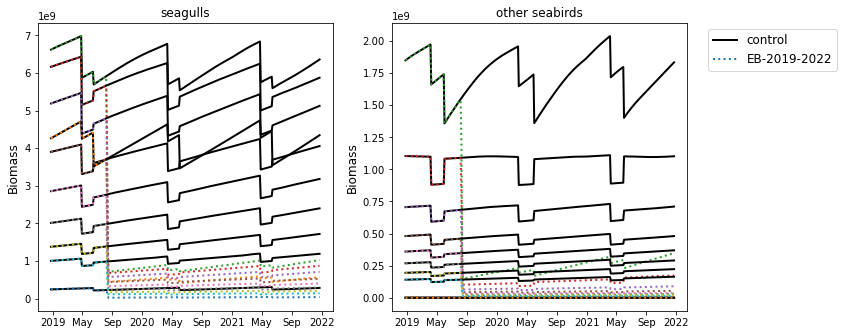

In [14]:
for control in control_datasets[0:1]:
    plot_vert_biomass(groups.birds, scenario_datasets[0:1], scenario_paths[0:1], control)

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `.Bbox`
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  contains: unknown
  figure: `.Figure`
  fontfamily or family: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'extra-expanded', 'ultra-expanded'}
  fontstyle or style: {'normal', 'italic', 'oblique'}
  fontvariant or variant: {'normal', 'small-caps'}
  font

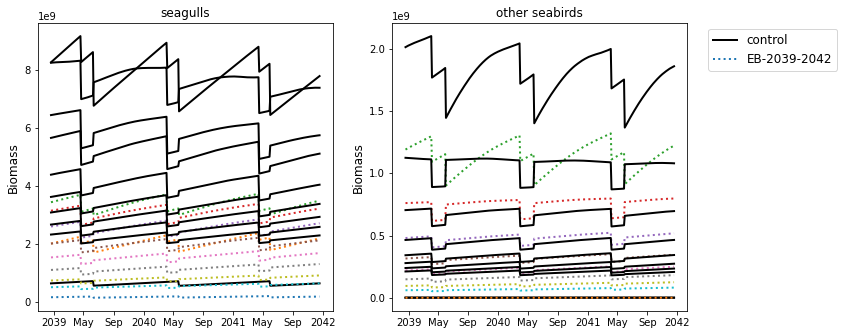

In [15]:
for control in control_datasets[2:3]:
    plot_vert_biomass(groups.birds, scenario_datasets[1:2], scenario_paths[1:2], control)

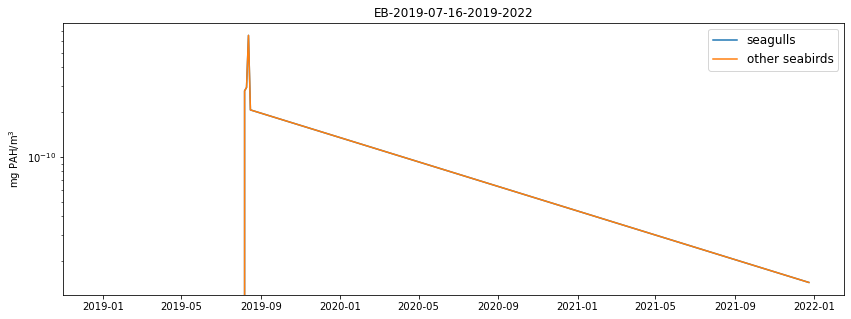

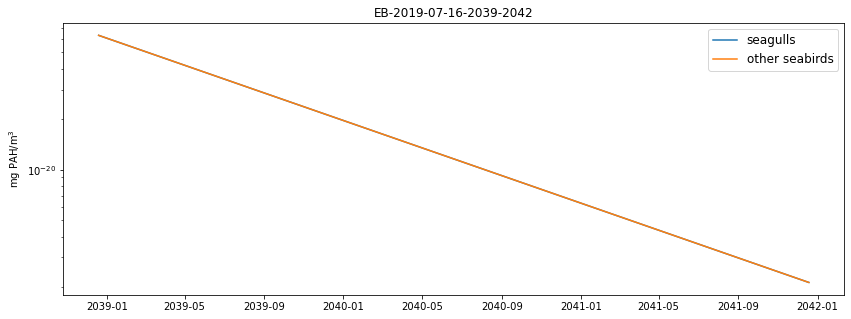

In [18]:
boxes = groups.salish_sea
for scenario, name in zip(scenario_datasets,scenario_names):
    fig, ax = plt.subplots(figsize = (14,5))
    for species in groups.birds:
        contam_tbl = 0
        for cohort in range (1, groups.cohorts[groups.birds[species]]+1):
            contam_tbl = contam_tbl + scenario.variables[groups.birds[species]+str(cohort)+'_Benzo'][:,boxes,0:6]
        contam_t = contam_tbl.sum(axis=(1,2))
        ax.semilogy(scenario.t, contam_t, label=species)
    ax.set_title(name, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(fontsize=12, ncol=1);